In [ ]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration - add models here as they become available
MODELS = {
    "mistral-medium-latest": {
        "contamination_dir": Path("phase3_bcq/mistral-medium-latest"),
        "performance_dir": Path("../v3/mistral_medium"),
    },
    # "gpt-4": {
    #     "contamination_dir": Path("phase3_bcq/gpt-4"),
    #     "performance_dir": Path("../v3/gpt4"),
    # },
}

PERFORMANCE_CONFIG = "c0"

In [2]:
def load_contamination(model_dir: Path) -> pd.DataFrame:
    """Load all contamination reports for a model."""
    records = []
    for f in model_dir.glob("*_contamination_report.json"):
        if f.name.startswith("dep_"):  # skip deprecated
            continue
        with open(f) as fp:
            data = json.load(fp)
            records.append({
                "dataset": data["dataset"],
                "min_contamination": data["min_contamination"],
                "max_contamination": data["max_contamination"],
            })
    return pd.DataFrame(records).sort_values("dataset").reset_index(drop=True)


def load_performance(perf_dir: Path, config_prefix: str) -> pd.DataFrame:
    """Load performance (macro-F1) from v3 results."""
    records = []
    for f in perf_dir.glob(f"{config_prefix}_*.json"):
        with open(f) as fp:
            data = json.load(fp)
            for ds, metrics in data["datasets"].items():
                f1 = metrics["reports"]["original"]["macro avg"]["f1-score"]
                records.append({"dataset": ds, "macro_f1": f1 * 100})
    return pd.DataFrame(records).sort_values("dataset").reset_index(drop=True)

In [3]:
# Load data for all models
all_data = []
for model_name, paths in MODELS.items():
    cont_df = load_contamination(paths["contamination_dir"])
    perf_df = load_performance(paths["performance_dir"], PERFORMANCE_CONFIG)
    merged = cont_df.merge(perf_df, on="dataset")
    merged["model"] = model_name
    all_data.append(merged)

df = pd.concat(all_data, ignore_index=True)
df

,dataset,min_contamination,max_contamination,macro_f1,model
0,ABSTRCT,68.0,68.0,76.430976,mistral-medium-latest
1,ACQUA,58.0,58.0,73.214286,mistral-medium-latest
2,AEC,36.0,36.0,44.444444,mistral-medium-latest
3,AFS,34.0,34.0,45.054945,mistral-medium-latest
4,ARGUMINSCI,52.0,52.0,57.637997,mistral-medium-latest
5,FINARG,42.0,42.0,36.507937,mistral-medium-latest
6,IAM,12.0,12.0,66.063348,mistral-medium-latest
7,PE,46.0,46.0,64.114833,mistral-medium-latest
8,SCIARK,68.0,68.0,86.666667,mistral-medium-latest
9,USELEC,46.0,46.0,56.228956,mistral-medium-latest


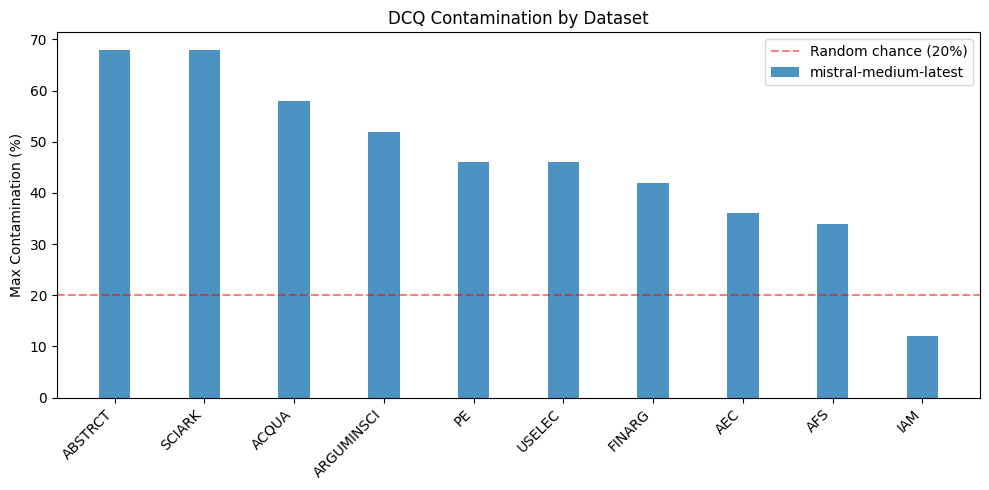

In [ ]:
# Plot 1: Contamination per dataset (bar chart with error bars)
fig, ax = plt.subplots(figsize=(10, 5))

for i, model in enumerate(df["model"].unique()):
    model_df = df[df["model"] == model].sort_values("max_contamination", ascending=False)
    x = range(len(model_df))
    
    # Bar showing range from min to max
    ax.bar(
        [xi + i * 0.35 for xi in x],
        model_df["max_contamination"],
        width=0.35,
        label=model,
        alpha=0.8,
    )
    
    if i == 0:  # Only set labels once
        ax.set_xticks(x)
        ax.set_xticklabels(model_df["dataset"], rotation=45, ha="right")

ax.axhline(y=20, color="red", linestyle="--", alpha=0.5, label="Random chance (20%)")
ax.set_ylabel("Max Contamination (%)")
ax.set_title("DCQ Contamination by Dataset")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Plot 2: Contamination vs Performance - Publication Quality
from scipy import stats
import numpy as np

# Style
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 7))

# Domain categories for color coding
DOMAINS = {
    "Scientific": ["ABSTRCT", "SCIARK", "ARGUMINSCI"],
    "Legal/Finance": ["ACQUA", "FINARG"],
    "Essays": ["AEC", "AFS", "PE"],
    "Discourse": ["IAM", "USELEC"],
}
DOMAIN_COLORS = {"Scientific": "#2ecc71", "Legal/Finance": "#3498db", "Essays": "#e74c3c", "Discourse": "#9b59b6"}

def get_domain(dataset):
    for domain, datasets in DOMAINS.items():
        if dataset in datasets:
            return domain
    return "Other"

for model in df["model"].unique():
    model_df = df[df["model"] == model].copy()
    model_df["domain"] = model_df["dataset"].apply(get_domain)
    
    x = model_df["max_contamination"].values
    y = model_df["macro_f1"].values
    
    # Regression line with CI
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min() - 5, x.max() + 5, 100)
    y_line = slope * x_line + intercept
    
    # Confidence interval
    n = len(x)
    y_pred = slope * x + intercept
    residuals = y - y_pred
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    x_mean = np.mean(x)
    ci = 1.96 * s_err * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
    
    ax.fill_between(x_line, y_line - ci, y_line + ci, alpha=0.15, color="steelblue")
    ax.plot(x_line, y_line, color="steelblue", linewidth=2, linestyle="--", alpha=0.8)
    
    # Scatter by domain
    for domain in DOMAINS.keys():
        domain_df = model_df[model_df["domain"] == domain]
        if len(domain_df) > 0:
            ax.scatter(domain_df["max_contamination"], domain_df["macro_f1"],
                      s=120, c=DOMAIN_COLORS[domain], label=domain, edgecolor="white", linewidth=1.5, zorder=5)
    
    # Labels with smart positioning
    for _, row in model_df.iterrows():
        offset = (8, 0) if row["max_contamination"] < 50 else (-40, 8)
        ax.annotate(row["dataset"], (row["max_contamination"], row["macro_f1"]),
                   fontsize=9, fontweight="medium", alpha=0.85,
                   xytext=offset, textcoords="offset points",
                   arrowprops=dict(arrowstyle="-", alpha=0.3, lw=0.5) if abs(offset[0]) > 10 else None)
    
    # Stats annotation box
    r_sq = r**2
    stats_text = f"r = {r:.2f}\np = {p:.3f}\nR² = {r_sq:.2f}"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.9))

ax.set_xlabel("DCQ Contamination (%)", fontsize=12, fontweight="medium")
ax.set_ylabel("Zero-Shot Macro F1 (%)", fontsize=12, fontweight="medium")
ax.set_title("Data Contamination Correlates with Task Performance", fontsize=14, fontweight="bold", pad=15)
ax.legend(title="Domain", loc="lower right", framealpha=0.9)
ax.set_xlim(5, 75)
ax.set_ylim(30, 95)

plt.tight_layout()
plt.savefig("contamination_vs_performance.pdf", dpi=300, bbox_inches="tight")
plt.savefig("contamination_vs_performance.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\n{'='*50}")
print("Key Finding: Higher contamination → Higher performance")
print(f"{'='*50}")
print(f"Pearson r = {r:.3f} (p = {p:.4f})")
print(f"R² = {r_sq:.3f} → {r_sq*100:.1f}% of performance variance explained by contamination")
print(f"\nSlope: +{slope:.2f} F1 points per 1% contamination increase")

In [ ]:
# Compare correlation across context levels (c0-c3)
CONTEXT_LABELS = {"c0": "No context", "c1": "Definition", "c2": "+ Guideline", "c3": "+ Document"}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

correlations = {}
for idx, (config, label) in enumerate(CONTEXT_LABELS.items()):
    ax = axes[idx]
    
    for model_name, paths in MODELS.items():
        cont_df = load_contamination(paths["contamination_dir"])
        perf_df = load_performance(paths["performance_dir"], config)
        merged = cont_df.merge(perf_df, on="dataset")
        
        x, y = merged["max_contamination"].values, merged["macro_f1"].values
        slope, intercept, r, p, _ = stats.linregress(x, y)
        correlations[config] = {"r": r, "p": p, "r_sq": r**2}
        
        # Regression line
        x_line = np.linspace(5, 75, 50)
        ax.plot(x_line, slope * x_line + intercept, "steelblue", lw=2, alpha=0.7)
        ax.scatter(x, y, s=60, c="steelblue", edgecolor="white", zorder=5)
        
        ax.set_title(f"{label}\nr={r:.2f}, p={p:.2f}", fontsize=11)
        ax.set_xlabel("Contamination (%)")
        ax.set_xlim(5, 75)
        ax.set_ylim(30, 95)

axes[0].set_ylabel("Macro F1 (%)")
plt.suptitle("Does Context Reduce the Contamination-Performance Link?", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("contamination_by_context.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary table
print("\nCorrelation Summary:")
print("-" * 45)
print(f"{'Context':<15} {'r':>8} {'p-value':>10} {'R²':>8}")
print("-" * 45)
for config, vals in correlations.items():
    sig = "*" if vals["p"] < 0.05 else ""
    print(f"{CONTEXT_LABELS[config]:<15} {vals['r']:>7.3f}{sig} {vals['p']:>10.3f} {vals['r_sq']:>8.1%}")
print("-" * 45)